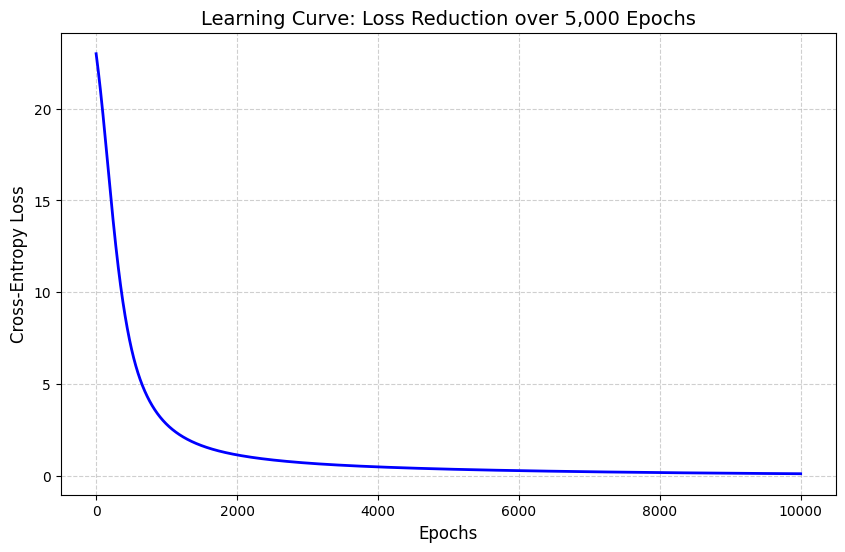

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

X_train_final = np.load('data/X_train_final.npz')['data']
y_train = np.load('data/y_train.npz')['data']
X_test_final = np.load('data/X_test_final.npz')['data']
y_test = np.load('data/y_test.npz')['data']

mean = X_train_final.mean(axis=0)
std = X_train_final.std(axis=0)

X_train = (X_train_final - mean) / std
X_test = (X_test_final - mean) / std


def one_hot(y, num_classes):
    out = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        out[i, int(y[i])] = 1
    return out


def softmax(logits):
    exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exps / np.sum(exps, axis=1, keepdims=True)


def gradient_step(X, y_onehot, probs, W, b, lr):
    error = probs - y_onehot
    num_samples = X.shape[0]

    dW = (1 / num_samples) * (X.T @ error)
    db = (1 / num_samples) * np.sum(error, axis=0)

    W -= lr * dW
    b -= lr * db

    return W, b

def cross_entropy_loss(y_onehot, probs):
    eps = 1e-12
    probs = np.clip(probs, eps, 1.0)
    return -np.mean(np.sum(y_onehot * np.log(probs), axis=1))

if __name__ == '__main__':
    y_train_oh = one_hot(y_train, 28)
    y_test_oh = one_hot(y_test, 28)

    n_features = X_train.shape[1]

    W = np.random.randn(n_features, 28)
    b = np.random.randn(28)

    lr = 0.1
    epochs = 10000

    loss_history = []

    for epoch in range(epochs):
        logits = X_train @ W + b
        probs = softmax(logits)

        W, b = gradient_step(X_train, y_train_oh, probs, W, b, lr)
        loss_history.append(cross_entropy_loss(y_train_oh, probs))

    test_logits = X_test @ W + b
    test_probs = softmax(test_logits)
    y_pred = np.argmax(test_probs, axis=1)
    y_pred_str = [str(y) for y in y_pred]
    np.savez_compressed('data/y_pred_logreg.npz', data=y_pred_str)

    # Plotting the training loss over time
    plt.figure(figsize=(10, 6))
    plt.plot(range(epochs), loss_history, color='blue', linewidth=2)

    # Labeling the axes for academic reporting
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.title("Learning Curve: Loss Reduction over 5,000 Epochs", fontsize=14)

    # Adding a grid for easier value reading
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()


In [ ]:
import numpy as np
from matplotlib import pyplot as plt

class MultinomialLogisticRegression:
    """
    מודל רגרסיה לוגיסטית מולטינומית (Softmax Regression).
    תומך בסיווג ליותר מ-2 מחלקות וכולל מנגנוני רגולריזציה למניעת התאמת-יתר.
    """
    
    def __init__(self, learning_rate=0.1, epochs=10000, reg_type=None, lambda_param=0.01):
        self.lr = learning_rate
        self.epochs = epochs
        self.reg_type = reg_type          
        self.lambda_param = lambda_param
        
        self.W = None                     
        self.b = None                     
        self.loss_history = []            
        self.num_classes = None

    def _one_hot(self, y):
        out = np.zeros((len(y), self.num_classes))
        for i in range(len(y)):
            out[i, int(y[i])] = 1
        return out

    def _softmax(self, logits):
        exps = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exps / np.sum(exps, axis=1, keepdims=True)

    def _compute_loss(self, y_onehot, probs):
        eps = 1e-12
        probs = np.clip(probs, eps, 1.0)
        
        base_loss = -np.mean(np.sum(y_onehot * np.log(probs), axis=1))
        
        if self.reg_type == 'l2':
            return base_loss + (self.lambda_param / 2) * np.sum(self.W ** 2)
        elif self.reg_type == 'l1':
            return base_loss + self.lambda_param * np.sum(np.abs(self.W))
            
        return base_loss

    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.num_classes = int(np.max(y)) + 1 
        y_onehot = self._one_hot(y)

        self.W = np.random.randn(num_features, self.num_classes)
        self.b = np.random.randn(self.num_classes)

        for epoch in range(self.epochs):
            logits = X @ self.W + self.b
            probs = self._softmax(logits)

            current_loss = self._compute_loss(y_onehot, probs)
            self.loss_history.append(current_loss)

            error = probs - y_onehot
            dW = (1 / num_samples) * (X.T @ error)
            db = (1 / num_samples) * np.sum(error, axis=0)

            if self.reg_type == 'l2':
                dW += self.lambda_param * self.W
            elif self.reg_type == 'l1':
                dW += self.lambda_param * np.sign(self.W)

            self.W -= self.lr * dW
            self.b -= self.lr * db

    def predict_proba(self, X):
        if self.W is None or self.b is None:
            raise ValueError("The model is not trained yet. Call 'fit' first.")
            
        logits = X @ self.W + self.b
        return self._softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


# ==========================================
# קוד ההפעלה הראשי (Main Execution Block)
# ==========================================
if __name__ == '__main__':
    # 1. טעינת נתונים
    X_train_final = np.load('data/X_train_final.npz')['data']
    y_train = np.load('data/y_train.npz')['data'].astype(int)  # <--- Add .astype(int)
    X_test_final = np.load('data/X_test_final.npz')['data']
    y_test = np.load('data/y_test.npz')['data'].astype(int)    # <--- Add .astype(int)

    # 2. עיבוד מקדים
    mean = X_train_final.mean(axis=0)
    std = X_train_final.std(axis=0)
    
    X_train = (X_train_final - mean) / (std + 1e-8)
    X_test = (X_test_final - mean) / (std + 1e-8)

    # רשימת הרגולריזציות שנרצה לבדוק
    reg_types = [None, 'l1', 'l2']
    
    # הכנת הגרף מראש כדי שנוכל להוסיף אליו את כל העקומות
    plt.figure(figsize=(10, 6))

    for reg in reg_types:
        # קביעת שם הרגולריזציה להדפסות ולשמירת הקבצים (None יהפוך ל 'none')
        reg_name = reg if reg is not None else 'none'
        print(f"--- Training model with {reg_name.upper()} regularization ---")

        # 3. יצירת מופע של המודל
        model = MultinomialLogisticRegression(
            learning_rate=0.1, 
            epochs=10000, 
            reg_type=reg,          
            lambda_param=0.001
        )

        # 4. אימון המודל
        model.fit(X_train, y_train)

        # 5. חיזוי על נתוני המבחן
        y_pred = model.predict(X_test)
        
        # שמירת התוצאות עם שם דינמי לפי סוג הרגולריזציה
        y_pred_str = [str(y) for y in y_pred]
        filename = f'data/y_pred_logreg_{reg_name}.npz'
        np.savez_compressed(filename, data=y_pred_str)
        print(f"Saved predictions to: {filename}\n")

        # הוספת עקומת הלמידה של המודל הנוכחי לגרף
        plt.plot(range(model.epochs), model.loss_history, label=f'{reg_name.upper()} Reg', linewidth=2)

    # 6. הצגת הגרף המסכם לאחר סיום הלולאה
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Cross-Entropy Loss", fontsize=12)
    plt.title("Learning Curves: Comparing Regularization Types", fontsize=14)
    plt.legend(fontsize=12) # הוספת מקרא כדי להבדיל בין הקווים
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

--- Training model with NONE regularization ---
